# DINOv3 Feature Visualization - Driving Footage (Autumn Leaves)

## Setup

In [1]:
import subprocess, os, sys

UV = '/root/.local/bin/uv'
INSTALL_CMD = [UV, 'pip', 'install', '--system'] if os.path.exists(UV) else [sys.executable, '-m', 'pip', 'install']

subprocess.run([
    *INSTALL_CMD,
    'torch', 'torchvision',
    'opencv-python-headless',
    'matplotlib',
    'numpy',
    'Pillow',
    'tqdm',
    'scikit-learn',
    'requests',
    'transformers',
], check=True)

Using Python 3.11.15 environment at: /usr
Checked 10 packages in 14ms


CompletedProcess(args=['/root/.local/bin/uv', 'pip', 'install', '--system', 'torch', 'torchvision', 'opencv-python-headless', 'matplotlib', 'numpy', 'Pillow', 'tqdm', 'scikit-learn', 'requests', 'transformers'], returncode=0)

In [2]:
import time, os

VIDEO_PATH = './driving.mp4'
VIDEO_URL  = 'https://www.dropbox.com/scl/fi/1rz965mtxwsnedl0i67ju/driving.mp4?rlkey=0j82wzoke3au4ucm50zz5s9t2&st=aj70ofst&dl=1'
RUN_DIR    = f'./runs/p77/{int(time.time())}'
FRAMES_DIR = f'{RUN_DIR}/frames'
OUTPUT_DIR = f'{RUN_DIR}/output'

In [3]:
import subprocess, os
import cv2
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from PIL import Image
from tqdm import tqdm
from sklearn.decomposition import PCA
from transformers import AutoImageProcessor, AutoModel

DEVICE = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

Using device: cuda


## 1. Download & Extract Frames

In [4]:
import requests

os.makedirs(FRAMES_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

if not os.path.exists(VIDEO_PATH):
    print('Downloading video...')
    r = requests.get(VIDEO_URL, stream=True)
    r.raise_for_status()
    with open(VIDEO_PATH, 'wb') as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)
    print('Done.')
else:
    print('Already downloaded.')

IMG_SIZE = 1120

def center_crop_resize(frame_bgr, size=IMG_SIZE):
    img = Image.fromarray(cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB))
    w, h = img.size
    s = min(w, h)
    img = img.crop(((w - s) // 2, (h - s) // 2, (w + s) // 2, (h + s) // 2))
    return img.resize((size, size), Image.LANCZOS)

cap = cv2.VideoCapture(VIDEO_PATH)
total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps   = cap.get(cv2.CAP_PROP_FPS)
frame_paths = []
saved = 0
print(f'{total} frames @ {fps:.1f} fps')
while True:
    ret, frame = cap.read()
    if not ret:
        break
    img = center_crop_resize(frame)
    path = f'{FRAMES_DIR}/{saved:04d}.png'
    img.save(path)
    frame_paths.append(path)
    saved += 1
cap.release()
print(f'Saved {saved} frames to {RUN_DIR}')

Done.
3597 frames @ 59.9 fps
Saved 3597 frames to ./runs/p77/1777051882


## 2. Load DINOv3

In [5]:
MODEL_NAME = 'facebook/dinov3-vitb16-pretrain-lvd1689m'
image_processor = AutoImageProcessor.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE).eval()

PATCH_SIZE = 16
N_PATCHES  = IMG_SIZE // PATCH_SIZE  # 70
print(f'Patch grid: {N_PATCHES}x{N_PATCHES}')

def get_features(img_path):
    img = Image.open(img_path).convert('RGB')
    inputs = image_processor(
        images=img,
        return_tensors='pt',
        do_resize=False,
        do_center_crop=False,
    )
    x = inputs['pixel_values'].to(DEVICE)
    with torch.no_grad():
        outputs = model(pixel_values=x, interpolate_pos_encoding=True)
    num_register_tokens = getattr(model.config, 'num_register_tokens', 0)
    patch_tokens = outputs.last_hidden_state[:, 1 + num_register_tokens:, :]
    expected_tokens = N_PATCHES * N_PATCHES
    if patch_tokens.shape[1] != expected_tokens:
        raise ValueError(f'Expected {expected_tokens} patch tokens, got {patch_tokens.shape[1]}')
    return patch_tokens.squeeze(0)  # (N, D)

preprocessor_config.json:   0%|          | 0.00/585 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/744 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/343M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Patch grid: 70x70


## 3. Feature Similarity (query point -> heatmap)

Query patch (56, 21), flat index 3941


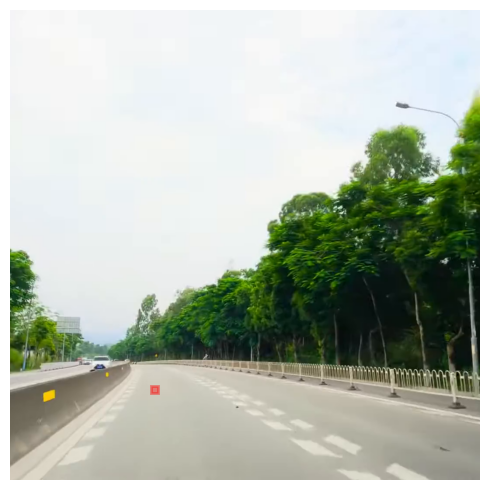

In [6]:
# Road patch (bottom-center of frame)
QUERY_X = 350
QUERY_Y = 900
QUERY_FRAME_IDX = 0

qr = QUERY_Y // PATCH_SIZE
qc = QUERY_X // PATCH_SIZE
q_idx = qr * N_PATCHES + qc
print(f'Query patch ({qr}, {qc}), flat index {q_idx}')

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(Image.open(frame_paths[QUERY_FRAME_IDX]))
ax.add_patch(plt.Rectangle((qc*PATCH_SIZE, qr*PATCH_SIZE), PATCH_SIZE, PATCH_SIZE,
                             linewidth=2, edgecolor='red', facecolor='red', alpha=0.4))
ax.axis('off')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/query_location.png', dpi=150)
plt.show()

In [8]:
q_feats = get_features(frame_paths[QUERY_FRAME_IDX])
q_vec   = F.normalize(q_feats[q_idx].unsqueeze(0), dim=-1)

SIM_DIR = f'{OUTPUT_DIR}/similarity'
os.makedirs(SIM_DIR, exist_ok=True)

for fi, fpath in enumerate(tqdm(frame_paths)):
    feats    = F.normalize(get_features(fpath), dim=-1)
    sim      = (feats @ q_vec.T).squeeze(-1).cpu().numpy()
    sim_img  = np.kron(sim.reshape(N_PATCHES, N_PATCHES), np.ones((PATCH_SIZE, PATCH_SIZE)))
    sim_norm = (sim_img - sim_img.min()) / (sim_img.max() - sim_img.min() + 1e-8)
    frame_np = np.array(Image.open(fpath))
    heat     = (cm.inferno(sim_img)[:, :, :3] * 255).astype(np.uint8)
    frame_marked = frame_np.copy()
    if fi == 0:
        cv2.rectangle(frame_marked, (qc*PATCH_SIZE, qr*PATCH_SIZE),
                      ((qc+1)*PATCH_SIZE, (qr+1)*PATCH_SIZE), (255,0,0), 2)
    side_by_side = np.concatenate([frame_marked, heat], axis=1)
    Image.fromarray(side_by_side).save(f'{SIM_DIR}/{fi:04d}.png')

subprocess.run([
    'ffmpeg', '-y', '-framerate', str(fps),
    '-i', f'{SIM_DIR}/%04d.png',
    '-c:v', 'libx264', '-pix_fmt', 'yuv420p',
    f'{OUTPUT_DIR}/similarity.mp4'
], check=True)
print('Done: similarity.mp4')

# similarity only (right half)
subprocess.run([
    'ffmpeg', '-y', '-framerate', str(fps),
    '-i', f'{SIM_DIR}/%04d.png',
    '-vf', f'crop={IMG_SIZE}:{IMG_SIZE}:{IMG_SIZE}:0',
    '-c:v', 'libx264', '-pix_fmt', 'yuv420p',
    f'{OUTPUT_DIR}/similarity_only.mp4'
], check=True)
print('Done: similarity_only.mp4')

100%|██████████| 3597/3597 [30:49<00:00,  1.94it/s]  
ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enabl

Done: similarity.mp4


Input #0, image2, from './runs/p77/1777051882/output/similarity/%04d.png':
  Duration: 00:01:00.01, start: 0.000000, bitrate: N/A
  Stream #0:0: Video: png, rgb24(pc), 2240x1120, 59.94 fps, 59.94 tbr, 59.94 tbn, 59.94 tbc
Stream mapping:
  Stream #0:0 -> #0:0 (png (native) -> h264 (libx264))
Press [q] to stop, [?] for help
[libx264 @ 0x5a6984a124c0] using cpu capabilities: MMX2 SSE2Fast SSSE3 SSE4.2 AVX FMA3 BMI2 AVX2
[libx264 @ 0x5a6984a124c0] profile High, level 4.2, 4:2:0, 8-bit
[libx264 @ 0x5a6984a124c0] 264 - core 163 r3060 5db6aa6 - H.264/MPEG-4 AVC codec - Copyleft 2003-2021 - http://www.videolan.org/x264.html - options: cabac=1 ref=3 deblock=1:0:0 analyse=0x3:0x113 me=hex subme=7 psy=1 psy_rd=1.00:0.00 mixed_ref=1 me_range=16 chroma_me=1 trellis=1 8x8dct=1 cqm=0 deadzone=21,11 fast_pskip=1 chroma_qp_offset=-2 threads=35 lookahead_threads=5 sliced_threads=0 nr=0 decimate=1 interlaced=0 bluray_compat=0 constrained_intra=0 bframes=3 b_pyramid=2 b_adapt=1 b_bias=0 direct=1 weightb=

Done: similarity_only.mp4


frame= 3597 fps= 32 q=-1.0 Lsize=   23684kB time=00:00:59.95 bitrate=3235.9kbits/s speed=0.538x    
video:23641kB audio:0kB subtitle:0kB other streams:0kB global headers:0kB muxing overhead: 0.183134%
[libx264 @ 0x5a6984a124c0] frame I:15    Avg QP:10.76  size: 14210
[libx264 @ 0x5a6984a124c0] frame P:906   Avg QP:13.10  size:  8306
[libx264 @ 0x5a6984a124c0] frame B:2676  Avg QP:16.77  size:  6154
[libx264 @ 0x5a6984a124c0] consecutive B-frames:  0.8%  0.0%  0.0% 99.2%
[libx264 @ 0x5a6984a124c0] mb I  I16..4: 95.9%  4.0%  0.1%
[libx264 @ 0x5a6984a124c0] mb P  I16..4: 18.9%  6.9%  0.2%  P16..4: 42.6%  5.4%  0.8%  0.0%  0.0%    skip:25.2%
[libx264 @ 0x5a6984a124c0] mb B  I16..4:  7.1%  2.5%  0.1%  B16..8: 45.1%  3.3%  0.0%  direct:13.0%  skip:29.0%  L0:52.0% L1:43.4% BI: 4.5%
[libx264 @ 0x5a6984a124c0] 8x8 transform intra:25.5% inter:96.2%
[libx264 @ 0x5a6984a124c0] coded y,uvDC,uvAC intra: 3.1% 29.3% 2.7% inter: 2.5% 23.2% 0.1%
[libx264 @ 0x5a6984a124c0] i16 v,h,dc,p: 52% 33% 15%  0%
[

## 4. PCA Visualization

In [9]:
all_feats = np.concatenate([
    get_features(fpath).cpu().numpy()
    for fpath in tqdm(frame_paths[::3][:60], desc='Collecting features')
], axis=0)
print(f'Feature matrix: {all_feats.shape}')

pca = PCA(n_components=3)
pca.fit(all_feats)
print(f'Explained variance: {pca.explained_variance_ratio_}')

Feature matrix: (294000, 768)
Explained variance: [0.26038125 0.18428622 0.11283544]


In [ ]:
PCA_DIR = f'{OUTPUT_DIR}/pca'
os.makedirs(PCA_DIR, exist_ok=True)

for fi, fpath in enumerate(tqdm(frame_paths, desc='PCA frames')):
    feats = get_features(fpath).cpu().numpy()
    proj  = pca.transform(feats)
    proj  = (proj - proj.min(0)) / (proj.max(0) - proj.min(0) + 1e-8)
    pca_map = np.kron(proj.reshape(N_PATCHES, N_PATCHES, 3), np.ones((PATCH_SIZE, PATCH_SIZE, 1)))
    pca_img = (pca_map * 255).astype(np.uint8)
    frame_np = np.array(Image.open(fpath))
    Image.fromarray(np.concatenate([frame_np, pca_img], axis=1)).save(f'{PCA_DIR}/{fi:04d}.png')

subprocess.run([
    'ffmpeg', '-y', '-framerate', str(fps),
    '-i', f'{PCA_DIR}/%04d.png',
    '-c:v', 'libx264', '-pix_fmt', 'yuv420p',
    f'{OUTPUT_DIR}/pca.mp4'
], check=True)
print('Done: pca.mp4')

# pca only (right half)
subprocess.run([
    'ffmpeg', '-y', '-framerate', str(fps),
    '-i', f'{PCA_DIR}/%04d.png',
    '-vf', f'crop={IMG_SIZE}:{IMG_SIZE}:{IMG_SIZE}:0',
    '-c:v', 'libx264', '-pix_fmt', 'yuv420p',
    f'{OUTPUT_DIR}/pca_only.mp4'
], check=True)
print('Done: pca_only.mp4')

PCA frames:  59%|█████▉    | 2121/3597 [15:50<12:36,  1.95it/s]

## 5. Preview

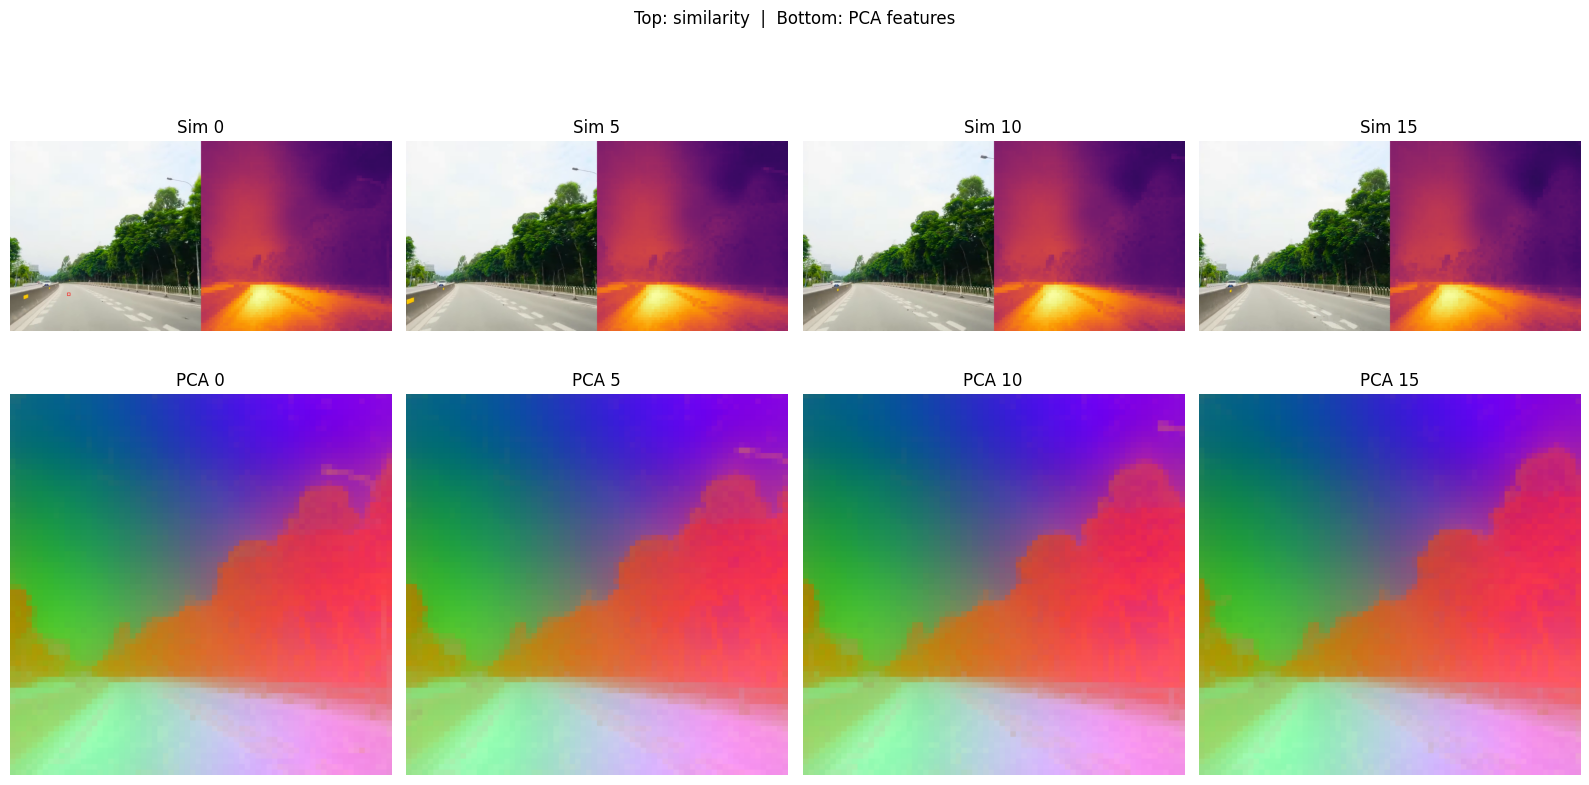

In [14]:
idxs = [0, 5, 10, 15]
fig, axes = plt.subplots(2, len(idxs), figsize=(4*len(idxs), 8))

for col, i in enumerate(idxs):
    sim_f = Image.open(f'{SIM_DIR}/{i:04d}.png')
    pca_f = Image.open(f'{PCA_DIR}/{i:04d}.png')
    w = pca_f.width // 2
    axes[0, col].imshow(sim_f); axes[0, col].axis('off'); axes[0, col].set_title(f'Sim {i}')
    axes[1, col].imshow(pca_f.crop((w, 0, pca_f.width, pca_f.height)))
    axes[1, col].axis('off'); axes[1, col].set_title(f'PCA {i}')

plt.suptitle('Top: similarity  |  Bottom: PCA features')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/preview.png', dpi=150)
plt.show()